In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style()

In [4]:
data = pd.read_csv("behaviour.csv")
data = data[data.condition.isin(("torque_intact", "torque_delay10", "pos_noproprio_eff2"))]

In [4]:
data.columns

Index(['condition', 'wandb_id', 'mode', 'dataset', 'level', 'behaviour',
       'n_clips', 'episode_reward_mean', 'lifespan_s_mean',
       'reward_per_step_mean', 'survived_mean', 'err_root_pos_m_mean',
       'err_root_angular_deg_mean', 'err_joint_l2_mean',
       'err_joint_vel_l2_mean', 'err_body_total_m_mean',
       'err_body_end_eff_m_mean', 'rtps_root_pos_mean', 'rtps_root_quat_mean',
       'rtps_joints_mean', 'rtps_joints_vel_mean', 'rtps_bodies_pos_mean',
       'rtps_end_eff_mean', 'rtps_torso_z_range_mean',
       'rtps_control_cost_mean', 'rtps_control_diff_cost_mean',
       'rtps_energy_cost_mean', 'episode_reward_median', 'episode_reward_sd',
       'episode_reward_sem', 'hazard_rate', 'frac_root_too_far',
       'frac_root_too_rotated', 'frac_pose_error', 'frac_nan_termination',
       'frac_survived'],
      dtype='object')

In [5]:
data[["condition", "wandb_id", "mode", "dataset", "level", "behaviour", "n_clips", "episode_reward_mean", "lifespan_s_mean", "hazard_rate"]]

,condition,wandb_id,mode,dataset,level,behaviour,n_clips,episode_reward_mean,lifespan_s_mean,hazard_rate
174,pos_noproprio_eff2,rfoe9wu2,position,new_eval,all,all,32,6258.125385,15.702500,0.047763
175,pos_noproprio_eff2,rfoe9wu2,position,new_eval,behaviour,Amble,8,5545.502007,13.795000,0.063429
176,pos_noproprio_eff2,rfoe9wu2,position,new_eval,behaviour,ProneSlow,1,4230.217773,10.560000,0.094697
177,pos_noproprio_eff2,rfoe9wu2,position,new_eval,behaviour,ProneSniff,18,7505.328375,18.748333,0.035559
178,pos_noproprio_eff2,rfoe9wu2,position,new_eval,behaviour,RearHigh,3,843.244812,2.390000,0.418410
...,...,...,...,...,...,...,...,...,...,...
401,torque_intact,ame77mw2,torque,train,behaviour,Rear,130,2131.873946,4.890000,0.000000
402,torque_intact,ame77mw2,torque,train,behaviour,Walk,141,2190.613281,4.829574,0.004405
403,torque_intact,ame77mw2,torque,train,coarse,groom,250,2182.905518,4.875920,0.000820
404,torque_intact,ame77mw2,torque,train,coarse,locomote,293,2169.976527,4.822833,0.004954


In [48]:
old_eval = data[data.dataset == "old_eval"]
old_eval = old_eval[old_eval.level.isin(["behaviour", "all"])]
old_eval.loc[old_eval.behaviour == "all", "behaviour"] = "All clips"

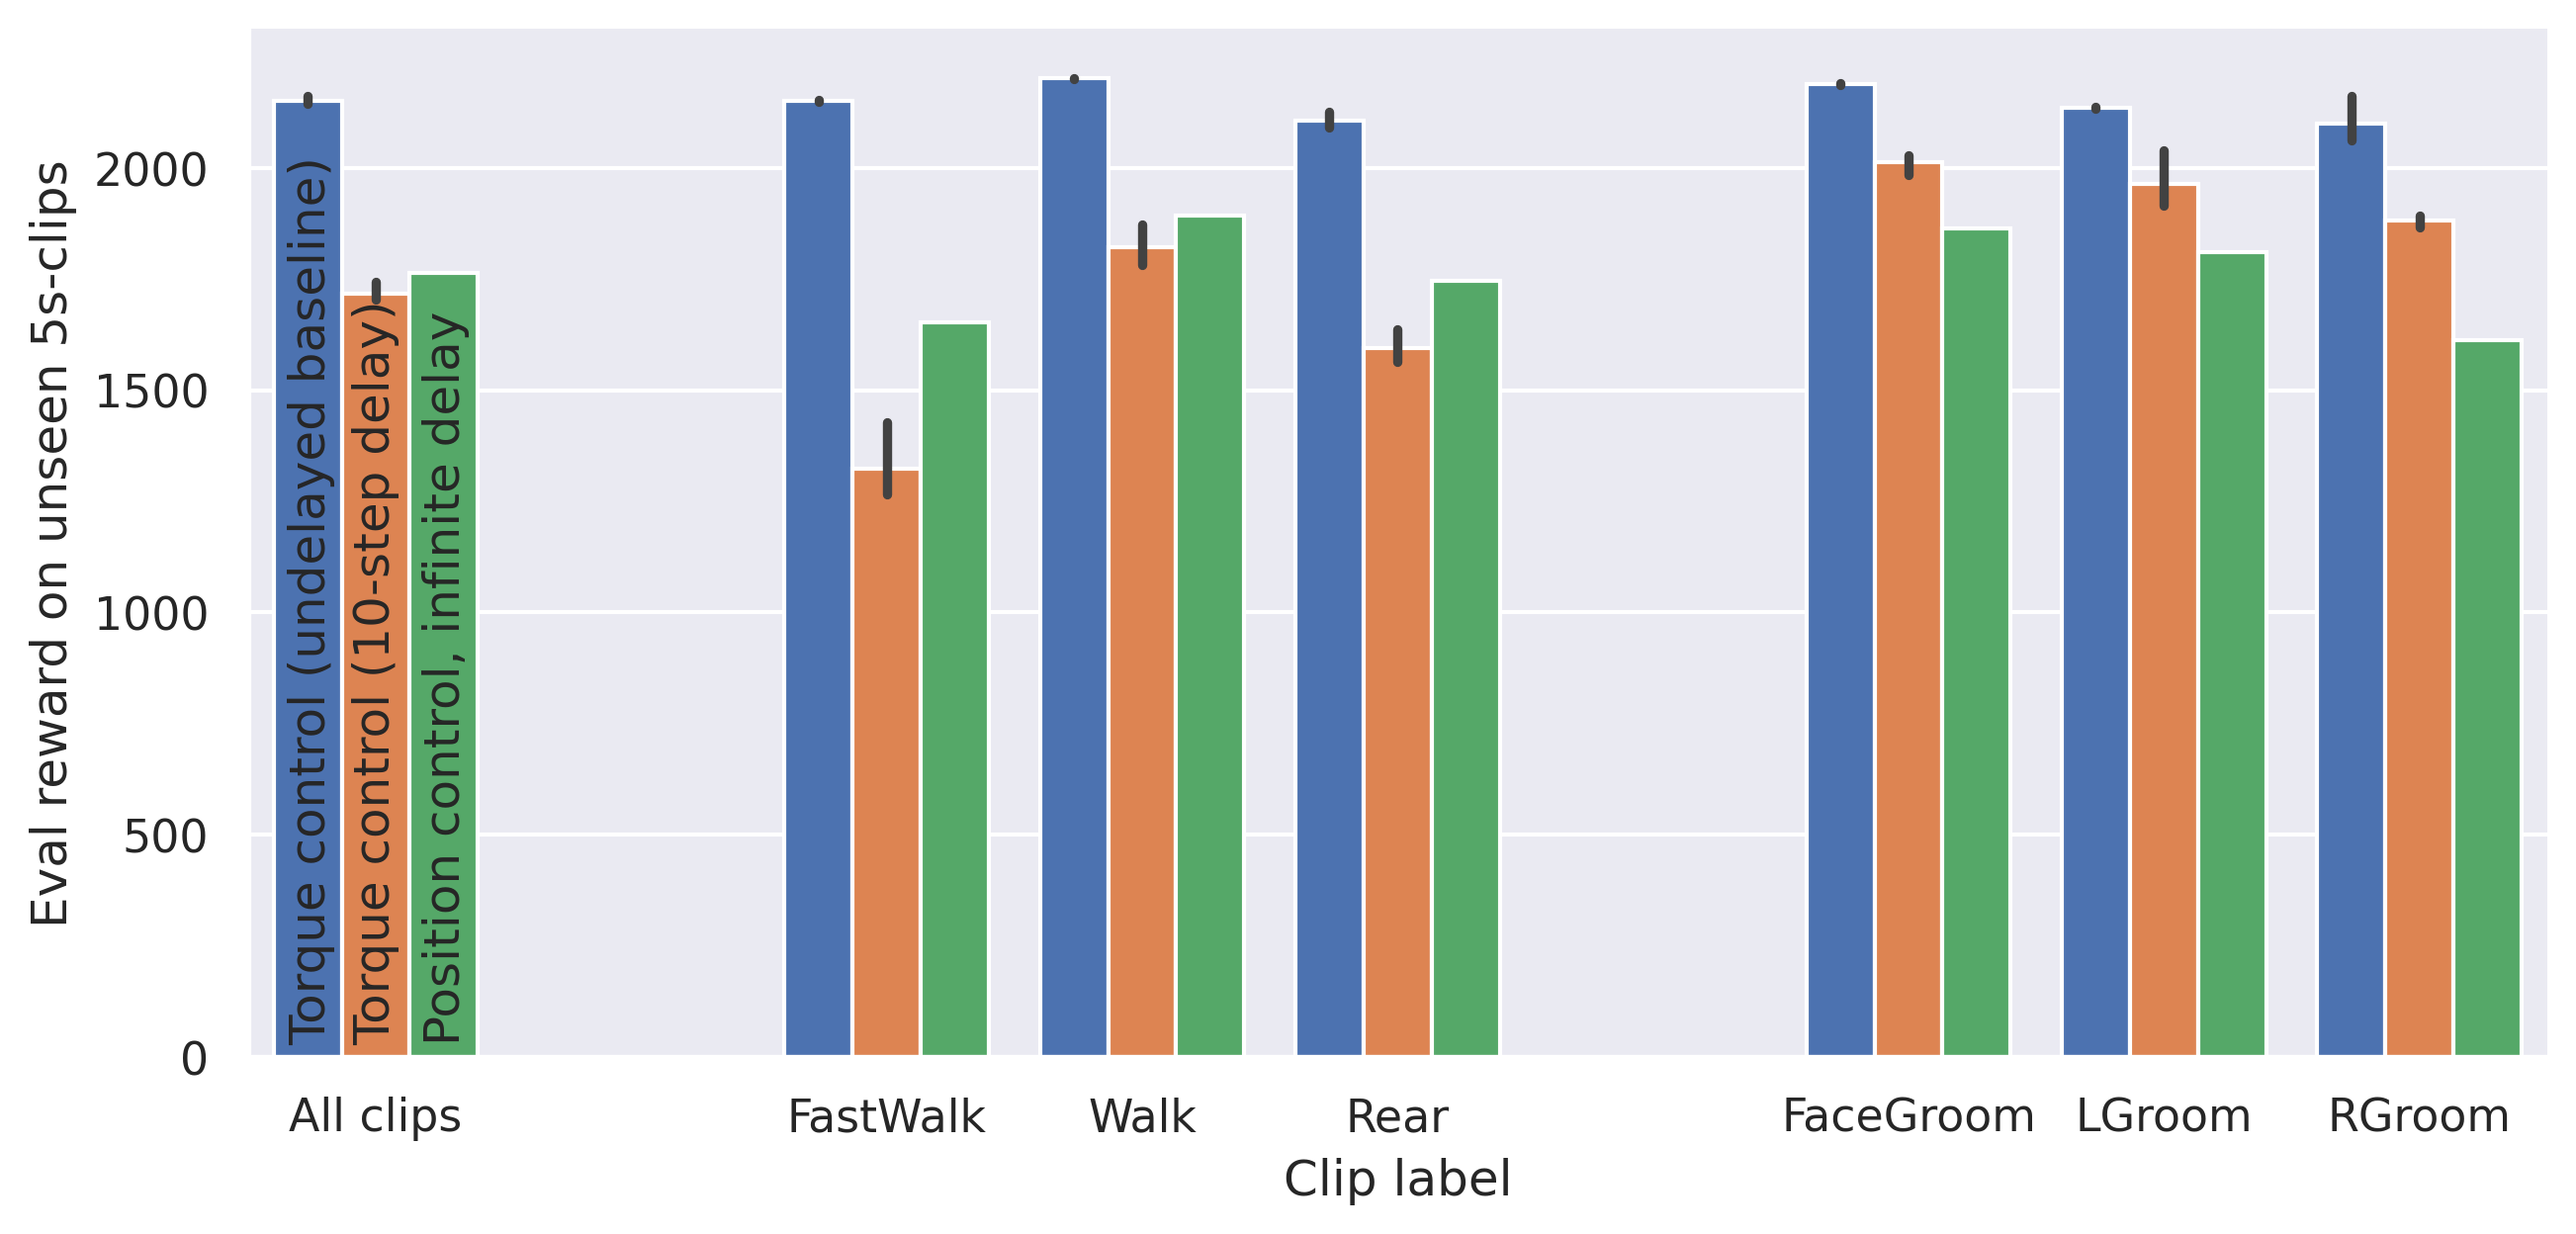

In [52]:
plt.figure(dpi=300, figsize=(10, 4.5))
sns.set_style("darkgrid")
sns.barplot(data=old_eval, x="behaviour", y="episode_reward_mean",
            hue="condition", hue_order=["torque_intact", "torque_delay10", "pos_noproprio_eff2"],
            order=["All clips", " ", "FastWalk", "Walk", "Rear", "  ", "FaceGroom", "LGroom", "RGroom"],
            legend=False, saturation=1)
plt.text(-0.25, 50, "Torque control (undelayed baseline)", rotation=90, ha="center")#, fontdict={"weight": 800})
plt.text(0.0, 50, "Torque control (10-step delay)", ha="center", rotation=90)# fontdict={"weight": 800})
plt.text(0.275, 50, "Position control, infinite delay", ha="center", rotation=90)
plt.xlabel("Clip label")
plt.ylabel("Eval reward on unseen 5s-clips")
sns.despine()

In [18]:
new_eval = data[data.dataset == "new_eval"]
new_eval = new_eval[new_eval.level.isin(["behaviour", "all"])]
new_eval.loc[new_eval.behaviour == "all", "behaviour"] = "All behaviors"
condition_labels = pd.Series({"torque_intact": "Torque control (undelayed baseline)",
                              "torque_delay10": "Torque control (10-step delay)",
                              "pos_noproprio_eff2": "Position control, infinite delay"},
                              name="condition_label")
new_eval = new_eval.join(condition_labels, on="condition")

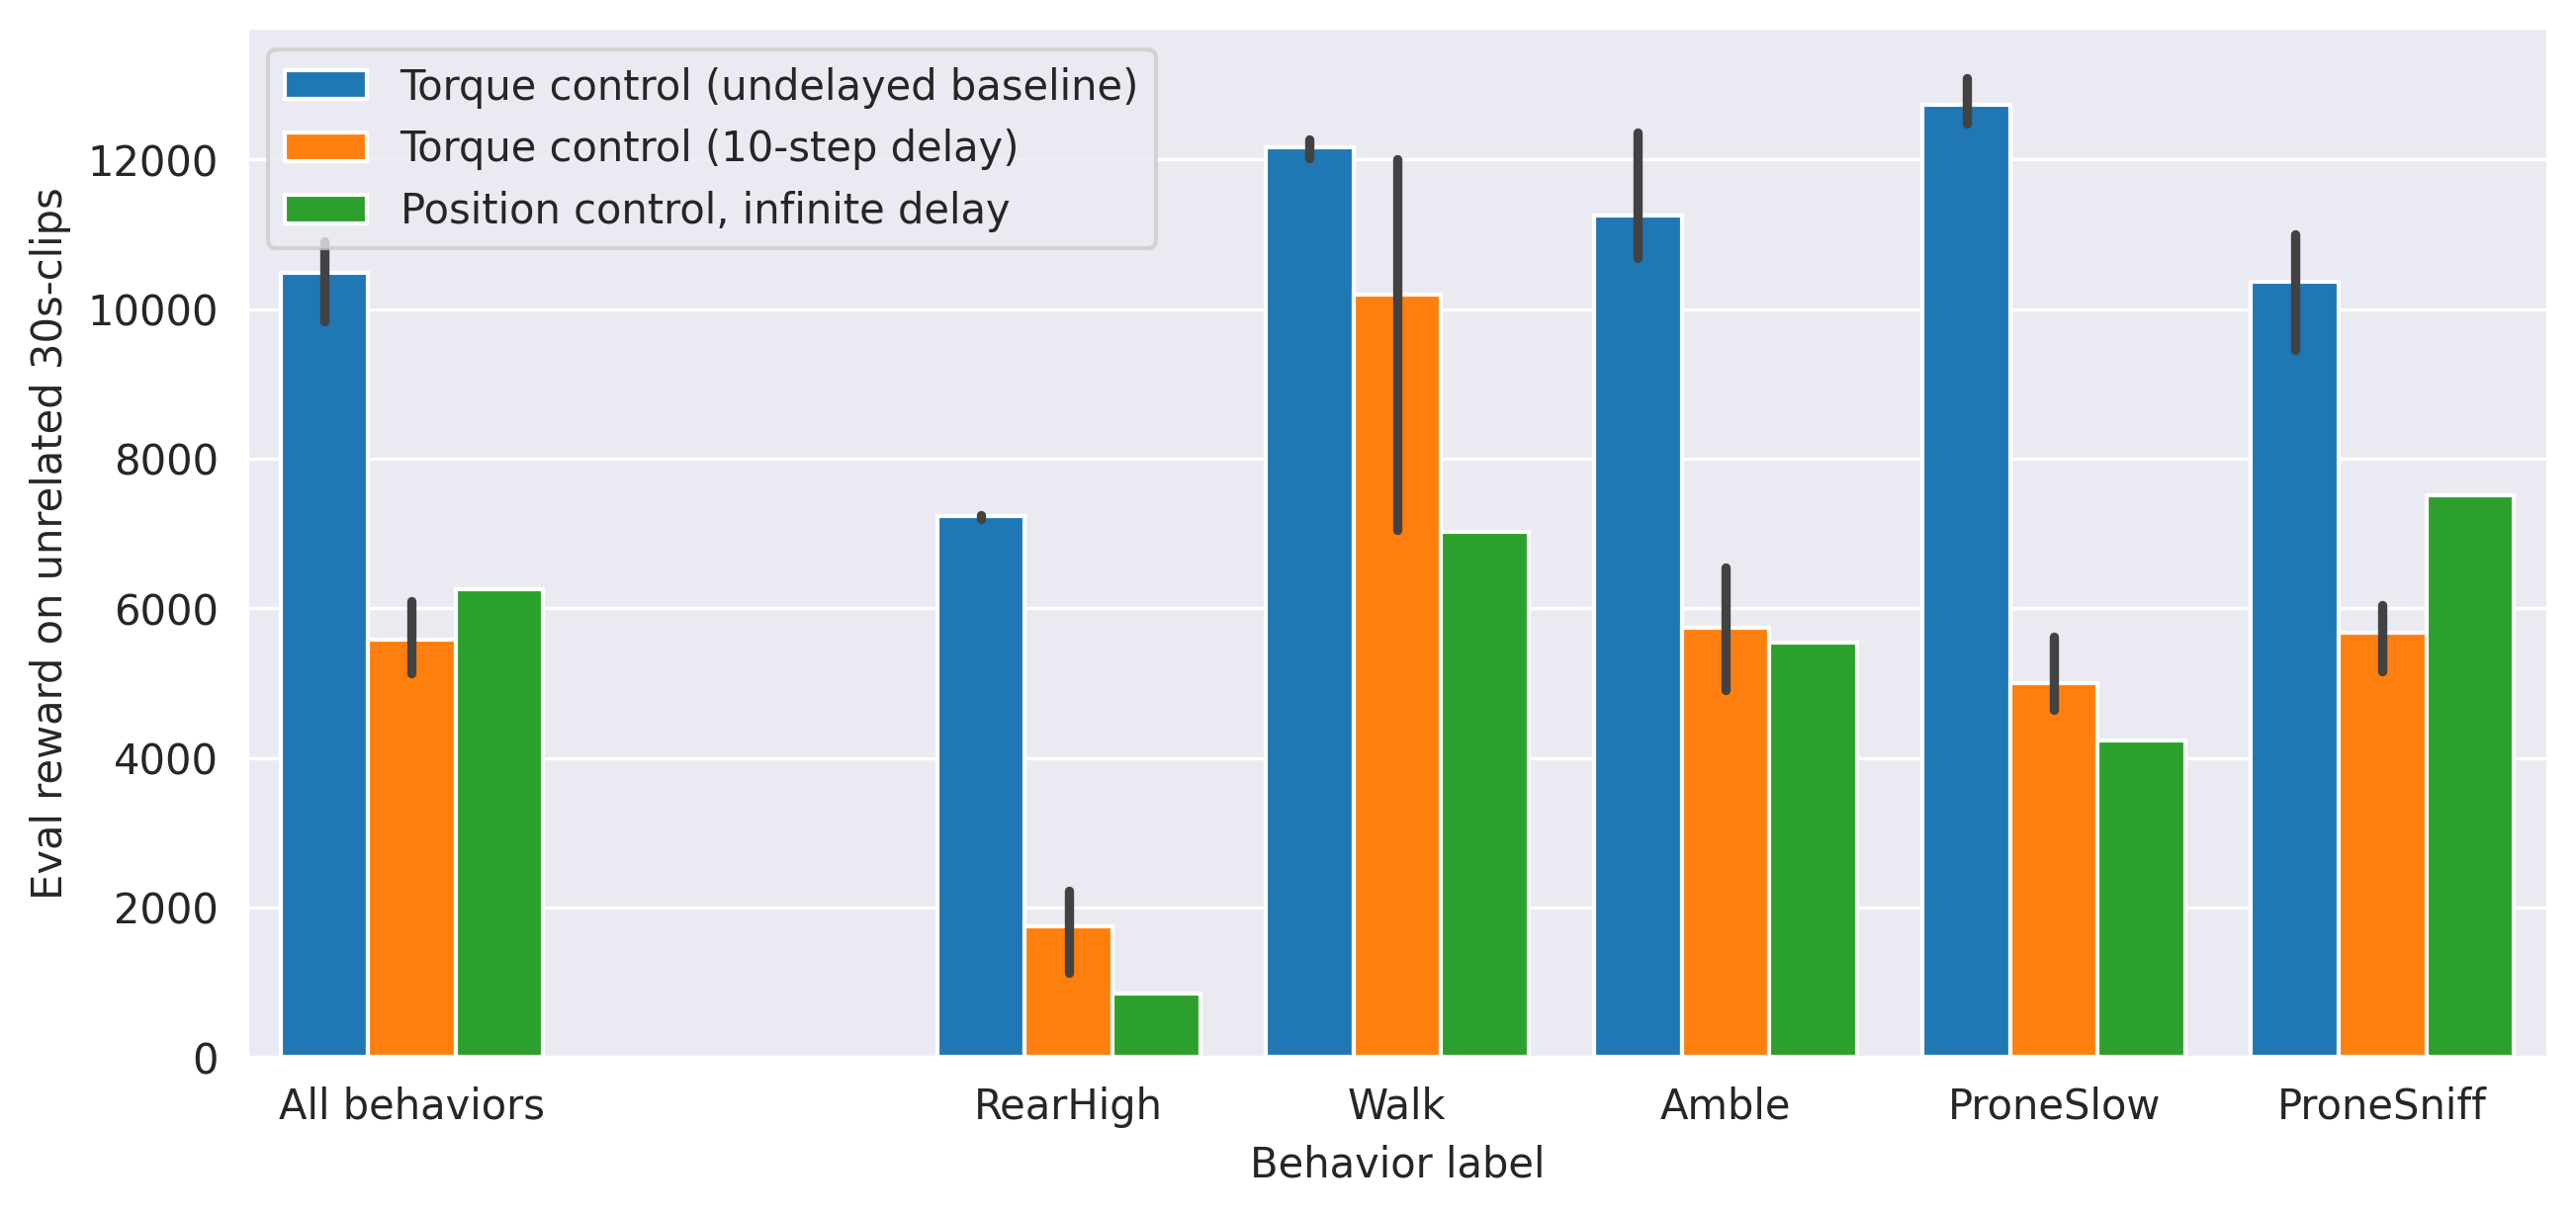

In [23]:
plt.figure(dpi=300, figsize=(10, 4.5))
sns.set_style("darkgrid")
sns.barplot(data=new_eval, x="behaviour", y="episode_reward_mean",
            hue="condition_label", hue_order=condition_labels.values,
            order=["All behaviors", " ", "RearHigh", "Walk", "Amble", "ProneSlow", "ProneSniff"],
            legend=True, saturation=1)
#plt.text(-0.25, 50, "Torque control (undelayed baseline)", rotation=90, ha="center")#, fontdict={"weight": 800})
#plt.text(0.0, 50, "Torque control (10-step delay)", ha="center", rotation=90)# fontdict={"weight": 800})
#plt.text(0.275, 50, "Position control, infinite delay", ha="center", rotation=90)
#plt.legend(labels=["Baseline", "Delay10", "PosInf"])
plt.legend(title=None)
plt.xlabel("Behavior label")
plt.ylabel("Eval reward on unrelated 30s-clips")
sns.despine()